# Training 3 different RNNs

In this notebook I will train 3 different RNNs, one simple RNN, one LSTM and one GRU.

In [4]:
import numpy as np
import pandas as pd
import os
import random
import joblib
from RNN_models import *
import torch
from torch import optim
from torchinfo import summary


device = torch.device("cpu")

data_folder = "../../MainProject/data/mediapipe_ugly_recordings"
n_frames = 30
n_features = 66
random_seed = 42

print(device)

cpu


In [5]:
def load(files, data_dir):
    dataframes = []

    for f in files:
        path = os.path.join(data_dir, f)   
        df = pd.read_csv(path)

        # Get rid of trailing whitespace
        df.columns = df.columns.str.strip()           
        dataframes.append(df)             

    combined = pd.concat(dataframes, ignore_index=True)  # combine all

    return combined

def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files


# Function to only use every n'th frame
def select_every_nth_frame(df, step=3):
    selected_cols = []

    for col in df.columns:
        # Extract frame number
        frame_part = col.split("_")[0]
        frame_idx = int(frame_part.replace("frame", ""))

        if frame_idx % step == 0:
            selected_cols.append(col)

    return df[selected_cols].copy()

# Modified Karl's augmentation function for training
def mirror_dataframe(df, mirror_x=True, mirror_y=True, mirror_z=True):
    """
    Mirror pose data by swapping left/right joints.

    Assumes column format: frameX_joint_coord
    """

    df_copy = df.copy()

    mirror_pairs = [
        ("left_shoulder", "right_shoulder"),
        ("left_elbow", "right_elbow"),
        ("left_hand", "right_hand"),
        ("left_hip", "right_hip"),
        ("left_knee", "right_knee"),
        ("left_foot", "right_foot"),
    ]

    for col in df.columns:
        parts = col.split("_")

        # Example: frame0_left_knee_x
        frame = parts[0]
        coord = parts[-1]
        joint = "_".join(parts[1:-1])

        for left, right in mirror_pairs:

            if joint == left:
                mirrored_col = f"{frame}_{right}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

            elif joint == right:
                mirrored_col = f"{frame}_{left}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

    return df_copy


In [6]:
from sklearn.preprocessing import StandardScaler

# Path to the mediapipe data we get after processing videos like it was described in the section above
data_folder = "../../MainProject/data/mediapipe_ugly_recordings"

# We use 70/30 train/test split due to lack of data
training_proportion = 0.7
validation_proportion = 0

# Split files
train_files, test_files = split_csvfiles(data_folder, random_seed, training_proportion, validation_proportion)

# Load df from files selected to be either training or testing
train_data = load(train_files, data_folder)
test_data = load(test_files, data_folder)

# Split input/target
y_train = train_data["target"]
x_train = train_data.drop(columns="target")
y_test = test_data["target"]
x_test = test_data.drop(columns="target")

# Make it a binary classification problem by mapping our 1-3 scores accordingly
mapping = {1: 0, 2: 1, 3: 1}
y_train = y_train.replace(mapping)
y_test = y_test.replace(mapping)

# Reduce amount of features by only using every n'th frame
x_train = select_every_nth_frame(x_train, step=3)
x_test = select_every_nth_frame(x_test, step=3)

# Perform augmentation and scaling on data
x_train_aug = pd.concat([x_train, mirror_dataframe(x_train)])
y_train_aug = np.concatenate([y_train, y_train])

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_aug)
x_test_scaled  = scaler.transform(x_test)

scaler_path = f"../data/scalers/Good_vs_Ugly_scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Convert the y array to numpy arrays too
y_train_np = np.asarray(y_train_aug)
y_test_np  = np.asarray(y_test)

# Convert to tensors
x_train = torch.tensor(x_train_scaled, dtype=torch.float32).to(device)
x_test   = torch.tensor(x_test_scaled, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train_np, dtype=torch.float32).to(device).view(-1, 1)
y_test = torch.tensor(y_test_np, dtype=torch.float32).to(device).view(-1, 1)

# Check dimensions for the preopared data
print(f"Test samples: {x_test.shape[0]}")
print(f"Train samples: {x_train.shape[0]}")
print(f"Total amount of features: {x_train.shape[1]}")
print(f"Total amount of samples: {x_train.shape[0] + x_test.shape[0]}")


# Start of my data shaping
x_train_recursive = torch.reshape(x_train, [-1, 10, 66])
x_test_recursive = torch.reshape(x_test, [-1, 10, 66])

print("\nShape of data: [batches, frames, features]")
print(f"recursive training: {x_train_recursive.shape}")
print(f"recursive test: {x_test_recursive.shape}")

print("\nShape of data: [batches, labels]")
print(f"training labels: {y_train.shape}")
print(f"test labels: {y_test.shape}")

n_features = x_train_recursive.shape[2]

Scaler saved to ../data/scalers/Good_vs_Ugly_scaler.joblib
Test samples: 61
Train samples: 284
Total amount of features: 660
Total amount of samples: 345

Shape of data: [batches, frames, features]
recursive training: torch.Size([284, 10, 66])
recursive test: torch.Size([61, 10, 66])

Shape of data: [batches, labels]
training labels: torch.Size([284, 1])
test labels: torch.Size([61, 1])


### Initialize the models

In [4]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset
import copy


def train_model(params: dict, train_data: torch.tensor, train_labels: torch.tensor, n_folds: int = 5) -> tuple[nn.Module, dict]:
    """
    Train model with cross-validation

    Args:
        params: Training parameters
        train_data: tesor of X data
        train_labels: tensor of Y data
        n_folds: Number of folds for cross-validation (default: 5)
    """

    # Compute weights of the labels to counteract an imbalanced dataset
    n_positive = 0
    n_negative = 0
    
    for Y in train_labels:
        if Y == 1:
            n_positive += 1
        else:
            n_negative += 1
    
    pos_weight = torch.tensor([n_negative / n_positive])

    results = {}

    # Perform k-fold cross-validation
    print(f"\nPerforming {n_folds}-fold cross-validation...")
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    fold_results = []
    fold_models = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(train_data)):
        print(f"\n--- Fold {fold + 1}/{n_folds} ---")

        # Split data
        train_x_fold = train_data[train_idx]
        train_y_fold = train_labels[train_idx]
        val_x_fold = train_data[val_idx]
        val_y_fold = train_labels[val_idx]

        # Train on this fold
        model, fold_stats = train_single_model(
            params, train_x_fold, train_y_fold, val_x_fold, val_y_fold, pos_weight, fold_num=fold + 1
        )

        fold_results.append(fold_stats)
        fold_models.append(model)

    # Aggregate cross-validation results
    results = aggregate_cv_results(fold_results)
    results['fold_models'] = fold_models
    results['cv_scores'] = [stats['final_val_accuracy'] for stats in fold_results]
    results['mean_cv_accuracy'] = np.mean(results['cv_scores'])
    results['std_cv_accuracy'] = np.std(results['cv_scores'])

    # Train final model on all data
    print("\n--- Training final model on all data ---")
    final_model, final_stats = train_single_model(
        params, train_data, train_labels, pos_weight, is_final=True
    )
    results['final_model'] = final_model
    results['final_stats'] = final_stats

    return final_model, results


def train_single_model(params: dict, train_data: torch.tensor, train_labels: torch.tensor,
                       val_data: torch.tensor = None, val_labels: torch.tensor = None,
                       pos_weight: torch.Tensor = None, fold_num: int = None,
                       is_final: bool = False) -> tuple[nn.Module, dict]:
    """Train a single model with validation"""

    model = params["model_type"](
        params["input_size"],
        params["hidden_size"],
        params["depth"],
        params["num_of_classification_labels"]
    ).to(device)

    optimizer = params["optimizer"](model.parameters(), lr=params["lr"])
    loss_func = params["loss_func"](pos_weight=pos_weight)

    train_dataset = TensorDataset(train_data, train_labels)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=False)

    if val_data is not None and val_labels is not None:
        val_dataset = TensorDataset(val_data, val_labels)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True, drop_last=False)

    prev_loss = np.inf
    streak = 0
    loss_increase = False
    loss_history = []
    val_loss_history = []
    val_accuracy_history = []
    early_stopping = False

    prefix = f"Fold {fold_num}" if fold_num else "Final" if is_final else "Model"
    print(f"{prefix} training with {params['epochs']} epochs")
    print("Start", " " * 10, "Finished")
    print("v", " " * 21, "v")

    interval = max(1, params["epochs"] // 25)

    for epoch in range(params["epochs"]):
        # Training phase
        model.train()
        total_loss = 0

        for X, Y in train_loader:

            output = model(X)
            loss = loss_func(output, Y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_data)
        loss_history.append(avg_loss)

        # Validation phase
        if val_data is not None and val_labels is not None:
            model.eval()
            val_loss = 0
            correct = 0
            total_samples = 0

            with torch.no_grad():
                for X, Y in val_loader:
                    output = model(X)
                    loss = loss_func(output, Y)
                    val_loss += loss.item()

                    # Calculate accuracy
                    _, predicted = torch.max(output, 1)
                    correct += (predicted == Y).sum().item()
                    total_samples += 1

            avg_val_loss = val_loss / len(val_data)
            val_accuracy = correct / total_samples
            val_loss_history.append(avg_val_loss)
            val_accuracy_history.append(val_accuracy)

            # Early stopping based on validation loss
            if avg_val_loss > prev_loss:
                loss_increase = True
            else:
                loss_increase = False
                # Save best model based on validation loss
                if not is_final:
                    best_model_state = copy.deepcopy(model.state_dict())

            if loss_increase:
                streak += 1
            else:
                streak = 0

            prev_loss = avg_val_loss
        else:
            # Early stopping based on training loss
            if avg_loss > prev_loss:
                loss_increase = True
            else:
                loss_increase = False

            if loss_increase:
                streak += 1
            else:
                streak = 0

            prev_loss = avg_loss

        # Early stopping check
        if streak >= params.get("patience", 5):
            early_stopping = True
            print("X")
            print(f"\nEarly stopping at epoch {epoch + 1}")
            break

        # Progress indicator
        if epoch % interval == 0:
            print("#", end="", flush=True)

    print() 

    # Load best model
    if val_data is not None and val_labels is not None and not is_final and 'best_model_state' in locals():
        model.load_state_dict(best_model_state)

    # Calculate final validation metrics
    final_val_accuracy = val_accuracy_history[-1] if val_accuracy_history else None
    best_val_accuracy = max(val_accuracy_history) if val_accuracy_history else None

    stats = {
        "loss_history": loss_history,
        "val_loss_history": val_loss_history,
        "val_accuracy_history": val_accuracy_history,
        "final_val_accuracy": final_val_accuracy,
        "best_val_accuracy": best_val_accuracy,
        "early_stopping": early_stopping,
        "n_epochs_trained": len(loss_history),
        "optimizer": optimizer
    }

    return model, stats


def aggregate_cv_results(fold_results: list) -> dict:
    """Aggregate results from cross-validation folds"""

    aggregated = {
        "cv_fold_results": fold_results,
        "val_accuracies": [r['final_val_accuracy'] for r in fold_results if r['final_val_accuracy']],
        "best_val_accuracies": [r['best_val_accuracy'] for r in fold_results if r['best_val_accuracy']],
        "n_epochs_per_fold": [r['n_epochs_trained'] for r in fold_results]
    }

    if aggregated['val_accuracies']:
        aggregated['mean_val_accuracy'] = np.mean(aggregated['val_accuracies'])
        aggregated['std_val_accuracy'] = np.std(aggregated['val_accuracies'])

    if aggregated['best_val_accuracies']:
        aggregated['mean_best_accuracy'] = np.mean(aggregated['best_val_accuracies'])

    print("\n" + "="*50)
    print("Cross-Validation Results:")
    if aggregated['val_accuracies'] and aggregated['std_val_accuracy']:
        print(f"  Mean validation accuracy: {aggregated['mean_val_accuracy']:.4f} ± {aggregated['std_val_accuracy']:.4f}")
    if aggregated['best_val_accuracies']:
        print(f"  Mean best accuracy: {aggregated['mean_best_accuracy']:.4f}")
    print(f"  Mean epochs trained: {np.mean(aggregated['n_epochs_per_fold']):.1f}")
    print("="*50)

    return aggregated

### Train the three models

In [5]:
models = []
models_stats = []
models_metadata = []

params_RNN = {
    "model_type": SimpleRNNModel,
    "input_size": n_features,
    "hidden_size": 32,
    "depth": 5,
    "num_of_classification_labels": 1,
    "lr": 0.0001,
    "loss_func": nn.BCEWithLogitsLoss,
    "optimizer": optim.Adam,
    "patience": 3,
    "epochs": 100
}
RNN, RNN_stats = train_model(params=params_RNN, train_data=x_train_recursive, train_labels=y_train)
models.append(RNN)
models_stats.append(RNN_stats)
models_metadata.append(params_RNN)

print(f"The final loss achieved: {RNN_stats["final_stats"]["loss_history"][-1]}")
model_summary = summary(RNN)
print(model_summary)


Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 2/5 ---
Fold 2 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 3/5 ---
Fold 3 training with 100 epochs
Start            Finished
v                       v
#####################X

Early stopping at epoch 85


--- Fold 4/5 ---
Fold 4 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 5/5 ---
Fold 5 training with 100 epochs
Start            Finished
v                       v
################X

Early stopping at epoch 65


Cross-Validation Results:
  Mean validation accuracy: 82.9000 ± 33.6517
  Mean best accuracy: 94.6000
  Mean epochs trained: 90.0

--- Training final model on all data ---
Final training with 100 epochs
Start            Finished
v                       v
##################

In [7]:
params_LSTM = {
    "model_type": LSTMModel,
    "input_size": n_features,
    "hidden_size": 32,
    "depth": 5,
    "num_of_classification_labels": 1,
    "lr": 0.0001,
    "loss_func": nn.BCEWithLogitsLoss,
    "optimizer": optim.Adam,
    "patience": 3,
    "epochs": 100
}
LSTM, LSTM_stats = train_model(params=params_LSTM, train_data=x_train_recursive, train_labels=y_train)
models.append(LSTM)
models_stats.append(LSTM_stats)
models_metadata.append(params_LSTM)

print(f"The final loss achieved: {LSTM_stats["final_stats"]["loss_history"][-1]}")
model_summary = summary(LSTM)
print(model_summary)


Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 2/5 ---
Fold 2 training with 100 epochs
Start            Finished
v                       v
##X

Early stopping at epoch 9


--- Fold 3/5 ---
Fold 3 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 4/5 ---
Fold 4 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 5/5 ---
Fold 5 training with 100 epochs
Start            Finished
v                       v
#########################

Cross-Validation Results:
  Mean validation accuracy: 88.0000 ± 35.8594
  Mean best accuracy: 95.3000
  Mean epochs trained: 81.8

--- Training final model on all data ---
Final training with 100 epochs
Start            Finished
v                       v
#########################
The final loss achieved: 0.001370

In [8]:
params_GRU = {
    "model_type": GRUModel,
    "input_size": n_features,
    "hidden_size": 32,
    "depth": 5,
    "num_of_classification_labels": 1,
    "lr": 0.0001,
    "loss_func": nn.BCEWithLogitsLoss,
    "optimizer": optim.Adam,
    "patience": 3,
    "epochs": 100
}
GRU, GRU_stats = train_model(params=params_GRU, train_data=x_train_recursive, train_labels=y_train)
models.append(GRU)
models_stats.append(GRU_stats)
models_metadata.append(params_GRU)

print(f"The final loss achieved: {GRU_stats["final_stats"]["loss_history"][-1]}")
model_summary = summary(GRU)
print(model_summary)


Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 2/5 ---
Fold 2 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 3/5 ---
Fold 3 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 4/5 ---
Fold 4 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 5/5 ---
Fold 5 training with 100 epochs
Start            Finished
v                       v
#########################

Cross-Validation Results:
  Mean validation accuracy: 84.4000 ± 34.3706
  Mean best accuracy: 95.3000
  Mean epochs trained: 100.0

--- Training final model on all data ---
Final training with 100 epochs
Start            Finished
v                       v
#########################
The final loss achieved: 0.00052727531

### Visualize the training

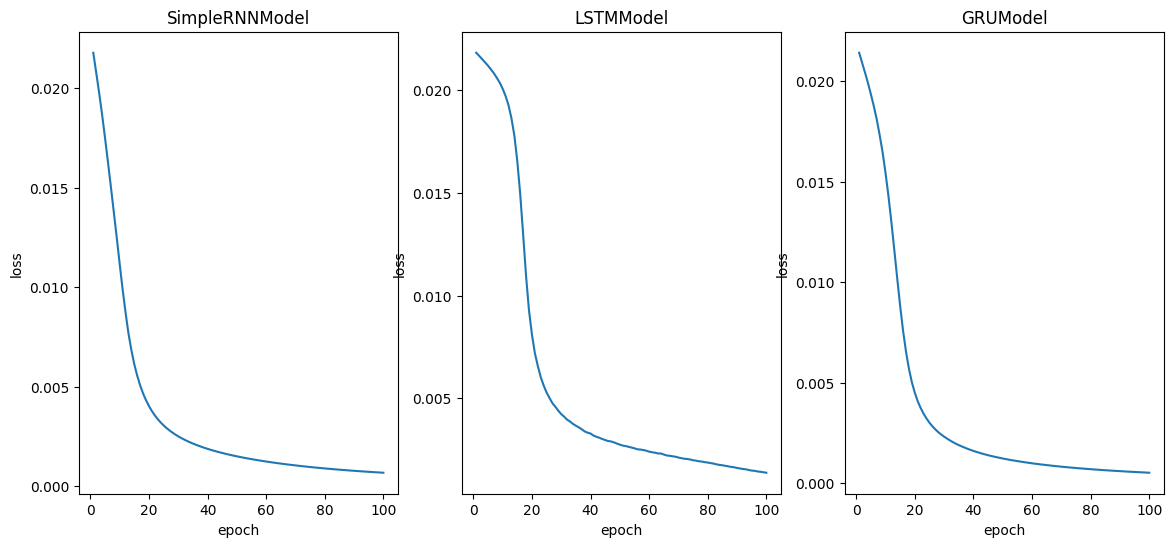

In [9]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(1, len(models), figsize=[14, 6])

for i, stats in enumerate(models_stats):
    if len(models) > 1:
        ax = axs[i]
    else:
        ax = axs
    ax.set_title(models[i].to_string())
    ax.plot([i for i in range(1, len(stats["final_stats"]["loss_history"]) + 1)], stats["final_stats"]["loss_history"])
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")

plt.show()

### Predict and evaluate

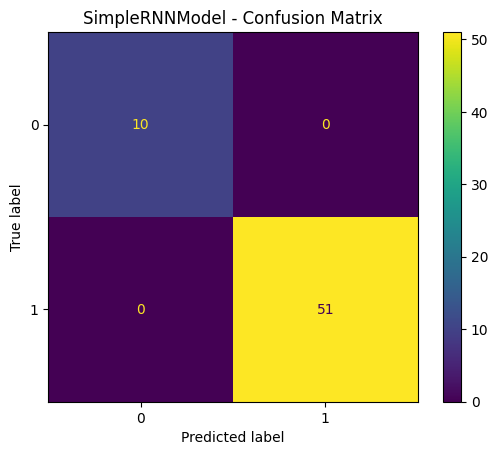

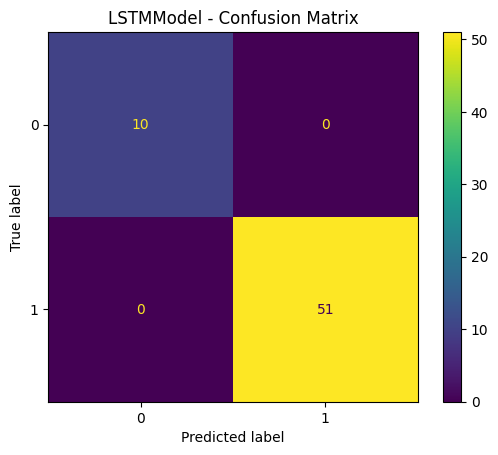

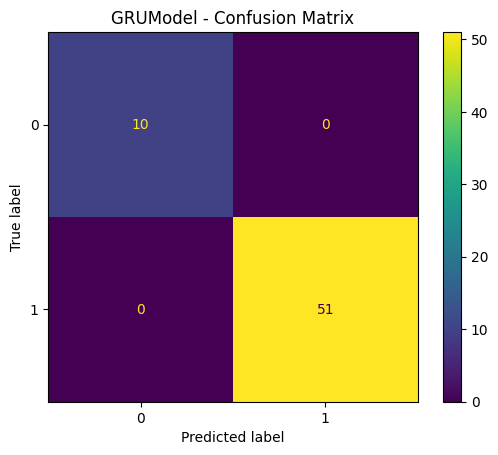

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for i, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        predictions = model(x_test_recursive).sigmoid().round()

        # Confusion matrix
        cm = confusion_matrix(y_test, predictions)

        disp = ConfusionMatrixDisplay(cm)
        disp.plot()
        plt.title(f"{models[i].to_string()} - Confusion Matrix")
        plt.show()

### Save model

In [ ]:
for i, model in enumerate(models):
    file_name = model.to_string() + "_checkpoint.pth"
    checkpoint = {
        "model_config": models_metadata[i],
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": models_stats[i]["final_stats"]["optimizer"].state_dict(),
        "model_statistics": models_stats[i]
    }
    torch.save(checkpoint, f"../models/RNN_models/{file_name}")
    print(f"Saved model {model.to_string()} to {file_name}")

KeyError: 'optimizer'